<h1>Modelos de Classificação </h1>
</br>

Letícia Borges dos Reis 2023005549

Maria Clara Rodrigues Ribeiro 2023005772

<h2>Importando as bibliotecas</h2>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns #para heatmap
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV #cross validation
from sklearn.linear_model import LogisticRegression #modelo de regressão logística
from sklearn.neighbors import NearestNeighbors #para encontrar epsilon do DBSCAN
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import DBSCAN
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay #métricas de avaliação do modelo
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from time import time

<h2>Importando Dataset e realizando tratamento e análise dos dados</h2>

O dataset utilizado apresenta amostras de observações espaciais feitas pelo SDDS e que contém 17 características diferentes. São elas:
* obj_ID: id do objeto no catálogo de imagens
* alpha \: "longitude" projetada no céu (ângulo)
* delta \: "latitude" projetada no céu  (ângulo)
* u \: filtro ultravioleta
* g \: filtro de espectro verde
* r \: filtro de espectro vermelho
* i \: filtro de infravermelho próximo
* z \: filtro de infravermelho
* run_ID \: identifica em qual "varredura" do telescópio a foto do objeto foi tirada
* rereun_ID \: número do reprocessamento da imagem
* cam_col \: identifica qual coluna da câmera do SDSS tirou a foto
* field_ID \: "campo" do céu que a foto foi tirada
* spec_obj_ID \: id do objeto no catálogo espectroscópio
* class \: galáxia, star ou quasar (coluna que tentaremos prever)
* redshift \: desvio para o vermelho (quanto o comprimento de luz "esticou" enquanto cruzava o espaço) -> possível indicativo de distância e velocidade (tirar isso daqui depois)
* plate \: id da placa de alumínio do SDSS que foi usada
* MJD \: "Modified Julian Date" -> data em que a observação foi feita
* fiber_ID \: id da fibra óptica da placa usada que foi apontada para o objeto

* **Fonte dos Dados:** [Kaggle - Stellar Classification Dataset - SDSS17](https://www.kaggle.com/datasets/fedesoriano/stellar-classification-dataset-sdss17)







```
.head() mostra os 5 primeiros dados para confirmar upload correto
```

In [ ]:
objects = pd.read_csv('/content/star_classification.csv')
objects.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


Dataset tem 100000 linhas

Rodando .info(), verifica-se que todas as colunas contém as 100000 não nulas (estão completas)




In [ ]:
objects.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

Com o comando _.describe()_, identificou-se que as colunas _'u', 'g' e 'z'_ apresentam valores mínimos de **-9999.000000** (extremamente distantes da média, mesmo considerando o desvio padrão *std*).

Essas colunas representam magnitude fotométrica (brilho da luz em um certo comprimento de onda). Logo, as chances de ser uma medição correta são mínimas, visto que se equivaleria à um "brilho negativamente infinito". Trata-se, então, de um valor artifical (usado para não deixar campo _null_).

Portanto, linhas que apresentam esse valor artifical (indicando possíveis erros de leitura do tellescópio), foram removidas do dataset para treinamento.

In [ ]:
objects.describe()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.237665e+18,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,4481.366060,301.0,3.511610,186.130520,5.783882e+18,0.576661,5137.009660,55588.647500,449.312740
std,8.438560e+12,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,1964.764593,0.0,1.586912,149.011073,3.324016e+18,0.730707,2952.303351,1808.484233,272.498404
min,1.237646e+18,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.237659e+18,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,3187.000000,301.0,2.000000,82.000000,2.844138e+18,0.054517,2526.000000,54234.000000,221.000000
50%,1.237663e+18,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,4188.000000,301.0,4.000000,146.000000,5.614883e+18,0.424173,4987.000000,55868.500000,433.000000
75%,1.237668e+18,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,5326.000000,301.0,5.000000,241.000000,8.332144e+18,0.704154,7400.250000,56777.000000,645.000000
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000


In [ ]:
stars = objects[(objects['u'] != -9999) & (objects['g'] != -9999) & (objects['z'] != -9999)]
stars.describe()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,9.999900e+04,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.0,99999.000000,99999.000000,9.999900e+04,99999.000000,99999.000000,99999.000000,99999.000000
mean,1.237665e+18,177.628653,24.135552,22.080679,20.631583,19.645777,19.084865,18.768988,4481.403354,301.0,3.511625,186.127011,5.783903e+18,0.576667,5137.027890,55588.653687,449.315613
std,8.438450e+12,96.502612,19.644608,2.251068,2.037384,1.854763,1.757900,1.765982,1964.739021,0.0,1.586913,149.007687,3.324026e+18,0.730709,2952.312485,1808.492217,272.498252
min,1.237646e+18,0.005528,-18.785328,10.996230,10.498200,9.822070,9.469903,9.612333,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.237659e+18,127.517698,5.147477,20.352410,18.965240,18.135795,17.732280,17.460830,3187.000000,301.0,2.000000,82.000000,2.844137e+18,0.054522,2526.000000,54234.000000,221.000000
50%,1.237663e+18,180.900527,23.646462,22.179140,21.099930,20.125310,19.405150,19.004600,4188.000000,301.0,4.000000,146.000000,5.614896e+18,0.424176,4987.000000,55869.000000,433.000000
75%,1.237668e+18,233.895005,39.901582,23.687480,22.123775,21.044790,20.396510,19.921120,5326.000000,301.0,5.000000,241.000000,8.332365e+18,0.704172,7400.500000,56777.000000,645.000000
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000


<h3>Remoção de Ouliers (DBSCAN) </h3>
Usou-se o algoritmo DBSCAN para identificar e remover os outliers do conjunto de dados.

Primeiramente, o dataset foi filtrado e normalizado para melhor desempenho do DBSCAN. Nessa etapa, retirou-se as variáveis de identificação (_ID) e as características técnicas do telescópio, visto que não são atributos físicos dos astros (não fornecendo, portanto, informações úteis para a classificação). Após esse filtro, os dados de entrada passaram a ter 8 dimensões.

Em seguida, utilizou-se o modelo Nearest Neighbors para determinar o valor de _epsilon_ (ao parâmetro _minPts_ foi atribuido o valor do dobro do número de dimensões dos dados de entrada).

Por fim, aplicou-se DBSCAN e removeu-se os dados rotulados com **-1** (outliers).

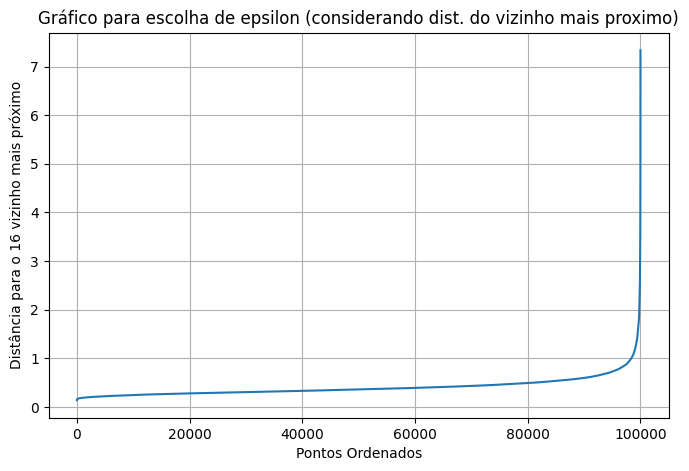

Foram detectados 1884 outliers
Restaram 98115 dados


In [ ]:
#retira classe (para não influenciar na clusterização) e colunas de identificadores (não são características usadas para classificar o objeto) -> caracteristicas e ids do telescopio
starsFeatures = stars.drop(columns=['class','obj_ID', 'run_ID', 'rerun_ID','cam_col', 'field_ID', 'spec_obj_ID', 'plate', 'MJD', 'fiber_ID'])

#normalizando os dados:
scaler = StandardScaler()
starsFeatures = scaler.fit_transform(starsFeatures)

minPts = 16 #2*dim dos dados (18 - 10 = 8) -> 10 dimensões "irrelevantes"
nbrs = NearestNeighbors(n_neighbors=minPts).fit(starsFeatures)
distances, indices = nbrs.kneighbors(starsFeatures)
distances = np.sort(distances[:, minPts-1])
plt.figure(figsize=(8,5))
plt.plot(distances)
plt.title('Gráfico para escolha de epsilon (considerando dist. do vizinho mais proximo)')
plt.xlabel('Pontos Ordenados')
plt.ylabel('Distância para o 16 vizinho mais próximo')
plt.grid(True)
plt.show()

#aplicando DBSCAN com eps = 0.75 e minPts = 16
dbscan = DBSCAN(eps = 0.75, min_samples=16)
labels = dbscan.fit_predict(starsFeatures)

#removendo outliers
outliers = (labels == -1).sum() #conta quantos dados DBSCAN rotulou como noise points (-1)
print(f"Foram detectados {outliers} outliers")
#máscara para remover outliers das variáveis e sua linha de classe
mask = (labels != -1)
starsFeatures = starsFeatures[mask] #mantém só os dados que não foram rotulados como outliers (!= -1)
print(f"Restaram {len(starsFeatures)} dados")

stars = stars.iloc[mask] # funciona como filtro .iloc (deixa somente dados nas posições de mask que são True)



<h3>Codificação de Labels e Dataframe</h3>
As classes encontram-se no dataset em formato textual ('GALÁXY', 'STAR', 'QSO').
Entretanto, para as operações matemáticas dos modelos, é ideal que os dados sejam numéricos. Logo, realizou-se a codificação dos rótulos (Label Encoding), transformando as classes em valores inteiros (0,1,2)

Além disso, após passar pelo scaler (normalização), o DataFrame original é convertido em uma matriz numérica (sem rótulos das colunas). Para análises futuras, reconstruiu-se o Dataframe, atribuindo novamente os cabeçalhos aos valores normalizados.

In [ ]:
#codificar classes (passar de String para numérico)
classes = stars['class']
le = LabelEncoder()
classes = le.fit_transform(classes)
print("Classes originais:", le.classes_)
print("Exemplo de classe codificada:", classes[154:160])

featureNames = stars.drop(columns=['class','obj_ID', 'run_ID', 'rerun_ID','cam_col', 'field_ID', 'spec_obj_ID', 'plate', 'MJD', 'fiber_ID']).columns
starsFeatures = pd.DataFrame(starsFeatures, columns = featureNames) #transforma vetor normalizado em Data Frame com nome de colunas, para análise
starsFeatures.head()

Classes originais: ['GALAXY' 'QSO' 'STAR']
Exemplo de classe codificada: [0 0 0 1 2 0]


,alpha,delta,u,g,r,i,z,redshift
0,-0.434597,0.425517,0.798798,0.806782,0.403953,0.046001,0.013999,0.079549
1,-0.339915,0.363391,1.198064,1.079967,1.584395,1.185087,1.611170,0.277088
2,-0.367244,0.582702,1.413732,0.997513,0.519736,0.150012,0.101520,0.092415
3,1.669522,-1.249122,0.024940,1.543642,1.059894,0.807601,0.272435,0.486761
4,1.737308,-0.150255,-1.174337,-1.497665,-1.697426,-1.767888,-1.825836,-0.630273


<h1> Análise Exploratória dos Dados </h1>

Usou-se a métrica de Informação Mútua (IM) para a análise de relações. A escolha baseou-se em sua capacidade de indicar relações e dependências não lineares entre variáveis, medindo o quanto de informação uma variável contém sobre a outra (o quanto sua presença reduz a incerteza sobre outra variável, excelente para quantificar o impacto de um atributo no resultado final).

De forma geral: IM = 0 indica que uma variável Y não contém nenhum informação sobre X (independência total); já valores próximos de 1 indicam alta dependência. Ou seja, quanto maior IM, maior a influência daquela característica na predição da classe (saída).

Ademais, foram gerados boxplots para analisar a distribuição de valores das variáveis para cada classe, a fim de confirmar visualmente os IM obtidos.

<h2> Análise de Resultados: </h2>

O gráfico de barras exibe a Informação Mútua entre cada _feature_ e a saída (classes). É evidente que o atributo **redshift** tem a maior influência na classificação, com um IM próximo de **0.8**.

**Alpha** e **delta**, por sua vez, são os atributos de menor influência para classificação (apresentam os menores valores de IM). Tal resultado era esperado, visto que representam apenas as "coordenadas"do astro no céu em relação ao telescópio, não tendo relação com a natureza física (alvo da classificação) do objeto. As demais características contêm semelhante influência na classificação, sendo a variável _z_ a de maior impacto entre elas.

Os boxplots validam visualmente esses números, ilustrando a distribuição dos valores dos atributos. Apesar de um boxplot fornecer várias estatísticas, o relevante para a nossa análise é a "caixa" (intervalo médio de valores). Com isso, observa-se que:

* _Features_ com baixo IM (como alpha e delta) possuem caixas fortemente sobrepostas. Isso significa que os intervalos de valores coincidem, tornando impossível distinguir um astro do outro apenas pela posição.
* Para  _features_ com alto IM (como redshift) o comportamento é o oposto. As caixas para cada classe ocupam intervalos bem distintos, com pouca ou nenhuma sobreposição (salvo alguns outliers, especialmente na classe "Galáxia"). Isso confirma que o redshift é um discriminador forte: seu valor fornece um grande indício da classe do objeto.

Tal informação também está de acordo com a física, já que o desvio para o vermelho indica o quão longe o astro está da Terra. Como os Quasares (QSO) são, em sua grande maioria, mais distantes que Galáxias e Estrelas, esperava-se que obtivessem valores maiores para essa característica (como ilustrado nos gráficos).

As demais características apresentam caixas que se sobrepõem em alguns valores, o que explica seus baixos IMs quando comparado ao de _redshift_. Quanto maior **IM**, menor a sobreposição dos valores dos atributos.

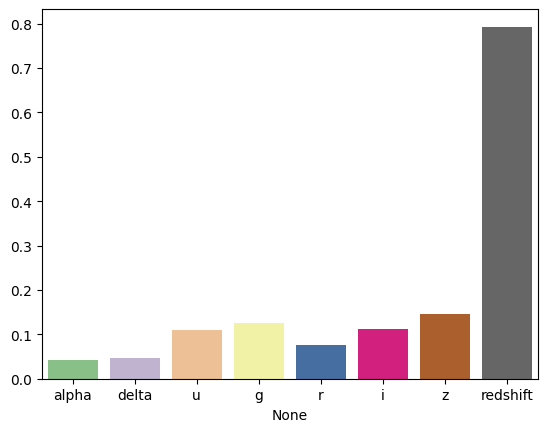

<Figure size 640x480 with 0 Axes>

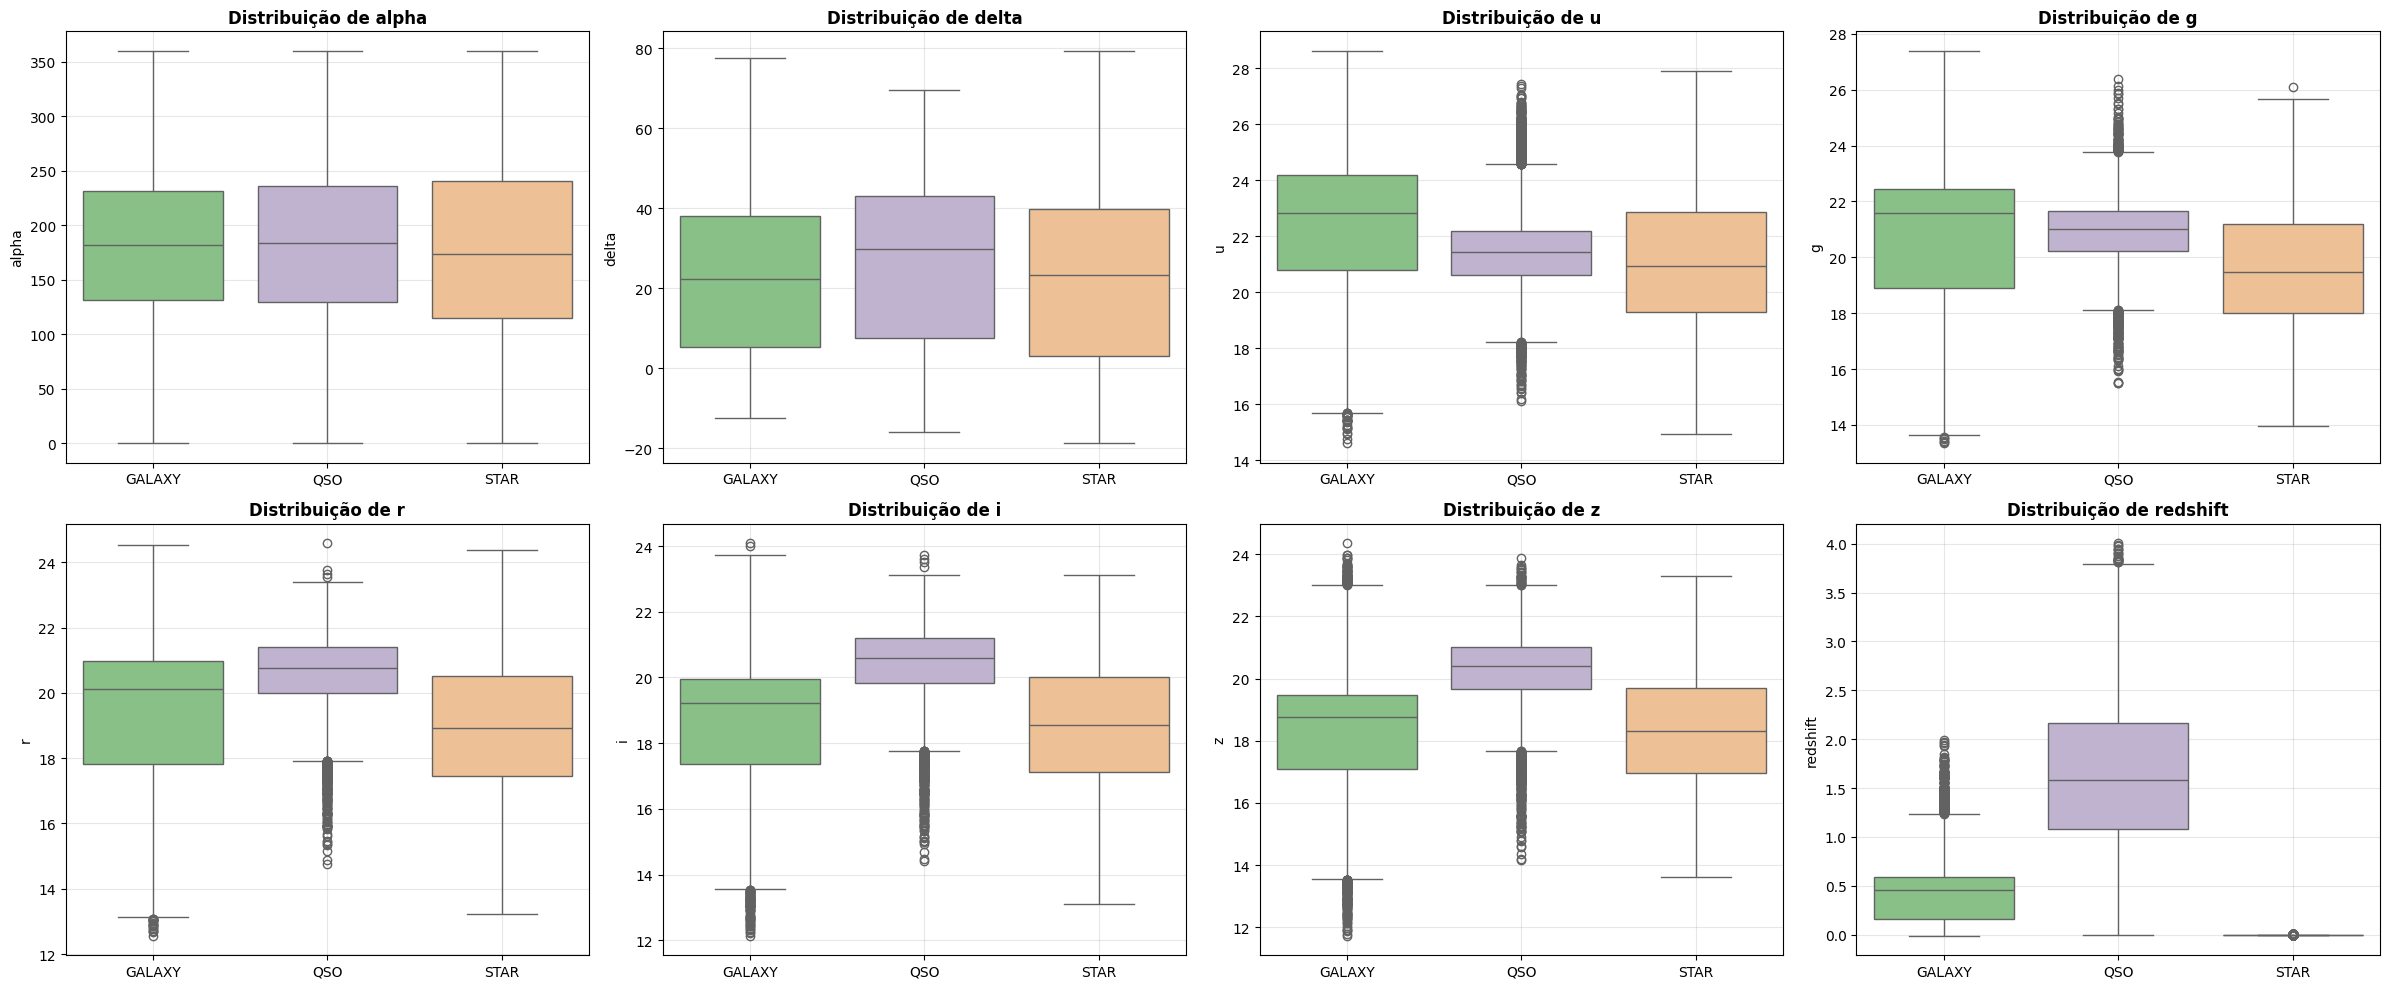

In [ ]:
mutual_info = mutual_info_classif(starsFeatures, classes)

plt.figure()
sns.barplot(x=starsFeatures.columns, y=mutual_info, hue=starsFeatures.columns, legend = False, palette = 'Accent')
plt.show()

plt.figure()
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(24, 10))
axes = axes.flatten()

for i, feature in enumerate(starsFeatures):
    sns.boxplot(ax=axes[i], x='class', y=feature, data=stars, hue = 'class', legend = False, palette="Accent") #usei stars para ter a coluna class tbm
    axes[i].set_title(f'Distribuição de {feature}', fontsize=12, fontweight='bold')
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(feature)
plt.tight_layout()
plt.show()

Divisão do dataset em dados de treino (80%) e dados de teste (20%)

In [ ]:
#test_size é o que indica a % de dados de teste
#random_state fixo garante que a divisão dos dados vai ser a mesma, independente de quantas vezes rodar a célula
#stratify distribui igualmente as classes entre os blocos de treino e teste (para garantir que vou ter exemplares de cada uma das classes para testar meu modelo)
starsTrain, starsTest, classTrain, classTest = train_test_split(starsFeatures, classes, test_size = 0.2, random_state = 42, stratify = classes)

# verificando divisão
print(f"Original: {starsFeatures.shape}")
print(f"Treino (80%): {starsTrain.shape}")
print(f"Teste (20%): {starsTest.shape}")

Original: (98115, 8)
Treino (80%): (78492, 8)
Teste (20%): (19623, 8)


<h2>Regressão Logística</h2>

Na célula abaixo, foi instanciado um modelo de Regressão Logística, treinado e testado com os dados separados anteriormente. Para a avaliação de desempenho, utilizou-se a função _classification_report_ para obter métricas de **acurácia** (porcentagem de acertos de rótulo), **precisão** (de todas as atribuições de pertencimento à uma classe X, quantos eram realmente desta classe), **recall** (quantos exemplares de uma classe rotulou como pertencentes à ela) e **f1-score** (média harmônica entre precisão e recall, indicando que o modelo apresenta bom desempenho em relação à verdadeiros positivos e verdadeiros negativos).

Como o dataset apresenta 3 classes de saída (multiclasse), o uso da função sigmóide (classificação binária) torna-se insuficiente. Dessa forma, para o modelo de **Regressão Logística multinomial** aplica automaticamente a função de ativação Softamax (distribui a probabilidade de pertencimento entre as três classes).

<h3>Resultados obtidos</h2>

* O modelo apresenta **acurácia** de **96%**, o que indica rotulagem correta em 96% dos dados de teste;

* **Galáxia**: o modelo apresentou métricas equilibradas, com precisão de **97%** e recall de **96%**, resultando em um f1-score de **96%**;

* **Quasar**: foi a classe em que o modelo apresentou maior dificuldade para rotular. Apesar de alta precisão (**95%**), o recall foi de **89%**, o que indica que o modelo deixou de identificar cerca de **11%** dos Quasares do conjunto. O **f1-score** de 91% reflete isso;

* **Estrela**: classe com o melhor desempenho relativo do modelo. Com precisão de **95%** e recall de **100%** (rotulou incorretamente apenas 1 estrela em todo o conjunto), apresentou o maior **f1-score**, com **97%**.

* A Matriz de Confusão ilustra esses percentuais em valores absolutos, permitindo compreensão de como as classes foram distribuídas e onde os erros do modelo se concentraram. Por exemplo, na linha dos Quasares observa-se que, dos erros cometidos, a grande maioria (412 amostras) foi classificada incorretamente como Galáxias.

<h3>Análise dos Resultados</h3>

No geral, o modelo apresentou excelente desempenho. Observa-se, entretanto, que as menores "taxas de acerto" ocorreram na classe Quasar. Um possível indicativo da causa é a distribuição dos valores de redshift (atributo de maior influência, conforme visto na Análise Exploratória).

Observa-se nos boxplots desse atributo que, apesar de intervalos bem delimitados para cada classe, existem inúmeros "outliers" da classe Galáxia que apresentam valores de **redshift** no mesmo intervalo que a maioria das amostras de Quasar.

Considerando que a Regressão Logística utiliza a função Softmax para gerar probabilidades de pertencimento ou não à uma classe, a sobreposição de valores de redshift nessas amostras pode gerar ambiguidade. Como os demais atributos físicos (cores) também possuem valores semelhantes entre Galáxias e Quasares, o redshift perde sua influência de "desempate" nesses casos específicos, levando o modelo a classificar os Quasares como Galáxias. Isso fica evidente na matriz de confusão: de todos os Quasares rotulados incorretamente, 412 viraram "Galáxias" e apenas 2 viraram "Estrelas".

Considerando a mesma lógica, a eficácia na rotulagem de Estrelas foi quase perfeita. Seus valores de redshift são muito distintos (próximos a zero) e distantes das outras classes, facilitando a criação de uma fronteira de decisão linear clara para o modelo. Evidencia-se pela matriz de confusão que apenas uma instância de Estrela não foi rotulada corretamente (indicada como Quasar), possivelmente sofrendo influência dos demais atributos.

Acurácia média com cross-validation: 0.9579574444387934

Relatório de Classificação:
              precision    recall  f1-score   support

      GALAXY       0.97      0.96      0.96     11813
         QSO       0.95      0.89      0.91      3611
        STAR       0.95      1.00      0.97      4199

    accuracy                           0.96     19623
   macro avg       0.95      0.95      0.95     19623
weighted avg       0.96      0.96      0.96     19623



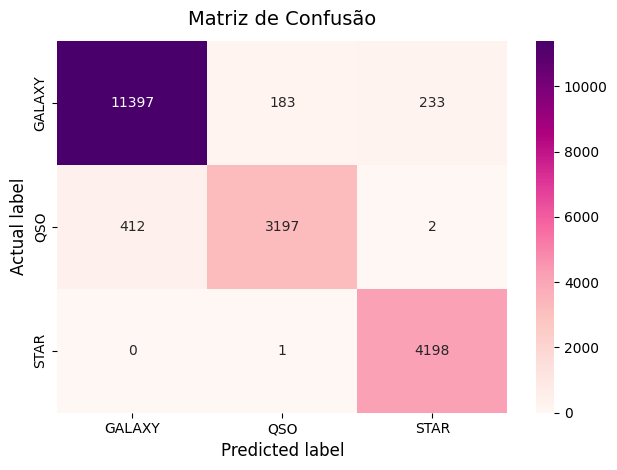

In [ ]:
lr = LogisticRegression() #instância do modelo de regressão logística

#cross-validation para "variar" dados de teste (blocos) e ter previsão de desempenho em relação À média de cada modelo com bloco de dado de teste diferente
#usa dados separados para treino para treinar e testar neles (mantendo starsTest exclusivament para validação final do modelo)
scores = cross_val_score(lr, starsTrain, classTrain)
print('Acurácia média com cross-validation:', scores.mean())


#treinar e testar com dados separados anteriormente:
lr.fit(starsTrain, classTrain) #ajusta modelo com dados de treino

starsPredictedlr = lr.predict(starsTest) #usar dados de teste (testar modelo) -> resultado é um vetor com as predições

# avaliar capacidade de generalização do modelo
print("\nRelatório de Classificação:")
print(classification_report(classTest, starsPredictedlr, target_names=le.classes_)) #usa nome das classes antes de codificar

#matriz de confusão
cm = confusion_matrix(classTest, starsPredictedlr)

plt.figure()
sns.heatmap(cm, annot=True, fmt='g', cmap='RdPu', xticklabels=le.classes_,  yticklabels=le.classes_)
plt.title('Matriz de Confusão', y=1.02, fontsize=14)
plt.ylabel('Actual label', fontsize=12)
plt.xlabel('Predicted label', fontsize=12)
plt.tight_layout()
plt.show()


Na célula a seguir, tem-se o mesmo código de regressão logística utilizado acima. Fez-se o teste apenas para verificar seleção automática de regressão multinomial no modelo acima.

Nesse teste, explicita-se o parâmetro de regressão multinomial. Os demais parâmetros foram selecionados seguindo o _default_ do modelo.

In [ ]:
lr = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000) #instância do modelo de regressão logística

#cross-validation para "variar" dados de teste (blocos) e ter previsão de desempenho em relação À média de cada modelo com bloco de dado de teste diferente
#usa dados separados para treino para treinar e testar neles (mantendo starsTest exclusivament para validação final do modelo)
scores = cross_val_score(lr, starsTrain, classTrain)
print('Acurácia média com cross-validation:', scores.mean())


#treinar e testar com dados separados anteriormente:
lr.fit(starsTrain, classTrain) #ajusta modelo com dados de treino

starsPredictedlr = lr.predict(starsTest) #usar dados de teste (testar modelo) -> resultado é um vetor com as predições

# avaliar capacidade de generalização do modelo
print("\nRelatório de Classificação:")
print(classification_report(classTest, starsPredictedlr, target_names=le.classes_)) #usa nome das classes antes de codificar


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

Acurácia média com cross-validation: 0.9579574444387934


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Relatório de Classificação:
              precision    recall  f1-score   support

      GALAXY       0.97      0.96      0.96     11813
         QSO       0.95      0.89      0.91      3611
        STAR       0.95      1.00      0.97      4199

    accuracy                           0.96     19623
   macro avg       0.95      0.95      0.95     19623
weighted avg       0.96      0.96      0.96     19623



<h2>Máquinas de Vetor de Suporte - SVM</h2>

Na célula abaixo, foi instanciado um modelo SVM, treinado e testado usando os dados separados anteriormente. A avaliação de desempenho utilizou as métricas padrão do _classification_report_ (**acurácia**, **precisão**, **recall** e **f1-score**) para cada classe.

<h3> Escolha de Hiperparâmetros</h3>

* Para a escolha do  C, realizou-se inúmeros testes de valores, definindo **C = 60** como o ponto ótimo. Valores inferiores (C baixo) resultavam em margens muito suaves, permitindo muitas violações. Por outro lado, valores superiores a 60 (C alto) tornavam a fronteira de decisão excessivamente rígida e ajustada aos dados de treino, prejudicando a generalização para os dados de teste.

* A escolha do kernel rbf deu-se graças à sua melhor capacidade de separar as diferentes classes do dataset. Ao calcular o hiperplano de separação dos dados em um espaço com mais dimensões, o modelo consegue definir melhores fronteiras de separação linear dos dados, apresentando resultados mais satisfatórios (hiperplano linear se torna curvas suaves de separação das classes).

* O parâmetro gama define quanta influência um único dado de treino tem. A biblioteca _scikit-learn_ apresenta o modo 'scale', que define automaticamente o melhor valor para gama. Para o modelo descrito, optou-se por utilizar o cálculo fornecido por ela.

Os resultados obtidos são ilustrados na tabela do _classification_report_, quantificados na **matriz de confusão**, e seguem a mesma lógica anteriormente descrita para a regressão logística.

<h3> Análise dos Resultados </h3>

Os valores das métricas de avaliação mostram desempenho muito semelhante ao obtido com o modelo de __regressão logística__, apresentando resultados minimamente melhores, com **acurácia** de 97%.

Essa melhora deve-se à forma como o SVM define à qual classe pertence uma observação. O modelo traça uma superfície de decisão para separar as classes e, ao utilizar a função de __kernel RBF__ (função de base radial), permite ao modelo alta eficácia mesmo para dados não linearmente separáveis. Dessa forma, conseguiu captar melhor as variâncias dos dados de entrada e, consequentemente, generalizar de forma mais satisfatória.

              precision    recall  f1-score   support

      GALAXY       0.98      0.98      0.98     11813
         QSO       0.97      0.92      0.95      3611
        STAR       0.97      1.00      0.98      4199

    accuracy                           0.97     19623
   macro avg       0.97      0.97      0.97     19623
weighted avg       0.97      0.97      0.97     19623



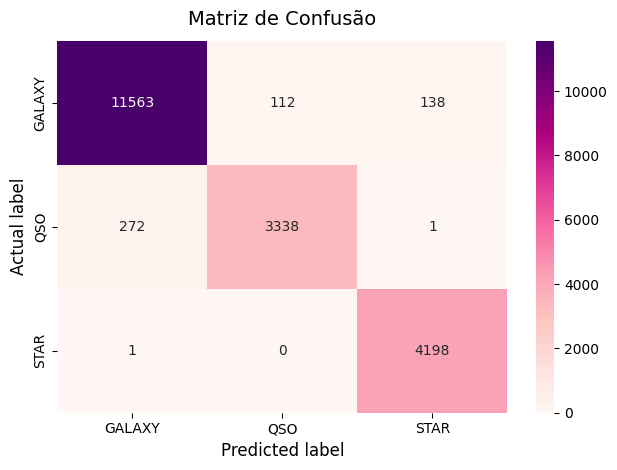

In [ ]:
# Create an SVM classifier with a radial basis function (RBF) kernel
svm_classifier = SVC(kernel='rbf', C=60, gamma='scale', random_state=42)

# Train the SVM classifier on the training data
svm_classifier.fit(starsTrain, classTrain)

# Make predictions on the test data
starsPredictedSVM = svm_classifier.predict(starsTest)

# Evaluate the performance of the SVM classifier
print(classification_report(classTest, starsPredictedSVM, target_names=le.classes_)) #usa nome das classes antes de codificar

#matriz de confusão
cmSVM = confusion_matrix(classTest, starsPredictedSVM)

plt.figure()
sns.heatmap(cmSVM, annot=True, fmt='g', cmap='RdPu', xticklabels=le.classes_,  yticklabels=le.classes_)
plt.title('Matriz de Confusão', y=1.02, fontsize=14)
plt.ylabel('Actual label', fontsize=12)
plt.xlabel('Predicted label', fontsize=12)
plt.tight_layout()
plt.show()

<h2>MLP (Multi-layer Perceptron)</h2>

Na célula abaixo, utiliza-se MLP (RNA) para classificação. Para análise de desempenho, utilizou-se novamente o _classification_report_ e a _matriz de confusão_. Além disso, plotou-se a curva de otimização da função de perda, para analisar em quantas iterações o modelo convergiu.

Os hiperparâmetros  _default_ da própria biblioteca, aplicados no modelo, são:
* Função de ativação: **ReLu**;
* Método de Otimização: **Adam**;
* Taxa de Aprendizagem: 0.0001;
* Quantidade de neurônios em 1 camada oculta: 100.

Optou-se por manter os hiperparâmetros padrão do Scikit-Learn (Adam, ReLU, 100 neurônios), visto que o modelo convergiu rapidamente e atingiu desempenho excelente (97%).

Como MLPs são muito sensíveis ao _Overfitting_, devido à sua alta complexidade, verificou-se a Acurácia do modelo para dados de treino e dados de teste.

<h3>Resultados Obtidos</h3>

* **Acurácia** = 97%;
* **Precisão** para Galáxia de 98%, Quasar 96% e Estrela 97%;
* **Recall** para Galáxia de 98%, Quasar 94% e Estrela 100%;
* **F1-Score** para Galáxia de 98%, Quasar 95% e Estrela 98%;


<h3>Análise de Resultados</h3>

O gráfico da função de perda mostra um decaimento acentuado que estabiliza rapidamente. Isso confirma que a rede neural conseguiu aprender os padrões  dos dados e convergir para um erro mínimo satisfatório (em torno de 0.10) em pouco mais de 20 iterações.

Com relação à verificação de  _Overfitting_, o modelo apresentou acurácia de **97.40%** nos dados de treino e **97.37%** nos dados de teste. Ou seja, a diferença de **0.03%** no desempenho mostra que o modelo não sofreu de overfitting. Isso se explica graças à grande quantidade de amostras no dataset, o que "equilibra" a complexidade do modelo (oferece ampla variância de entrada, impedindo que o modelo "decore" a saída e "forçando" o aprendizado).



Classification report:
              precision    recall  f1-score   support

      GALAXY       0.98      0.98      0.98     11813
         QSO       0.97      0.93      0.95      3611
        STAR       0.97      1.00      0.98      4199

    accuracy                           0.97     19623
   macro avg       0.97      0.97      0.97     19623
weighted avg       0.97      0.97      0.97     19623



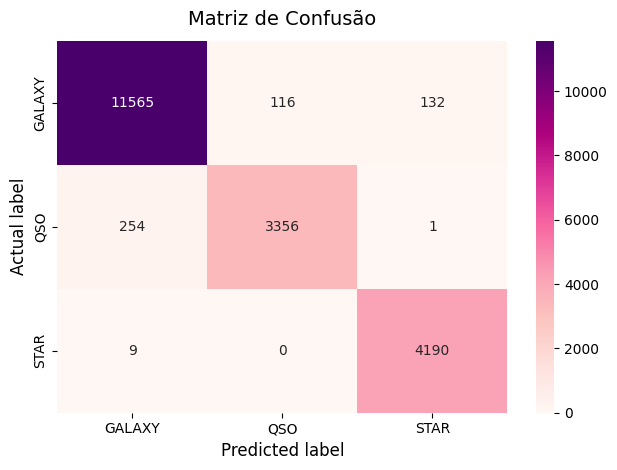

Acurácia no Treino: 0.9751
Acurácia no Teste:  0.9739


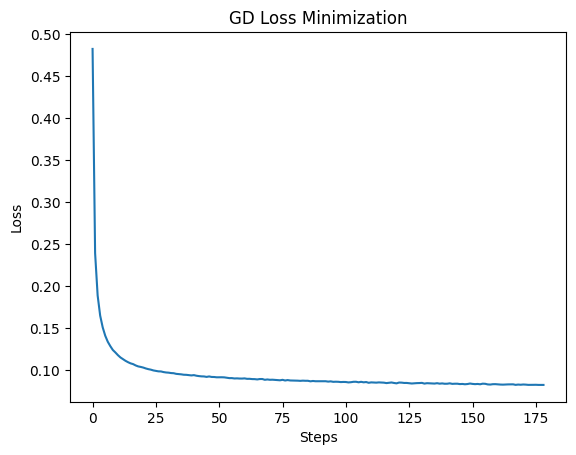

In [ ]:
mlp = MLPClassifier()

mlp.fit(starsTrain, classTrain)

starsPredictedMLP = mlp.predict(starsTest)

# Evaluate the performance of the  classifier
print('Classification report:')
print(classification_report(classTest, starsPredictedMLP, target_names=le.classes_)) #usa nome das classes antes de codificar

#matriz de confusão
cmMLP = confusion_matrix(classTest, starsPredictedMLP)
plt.figure()
sns.heatmap(cmMLP, annot=True, fmt='g', cmap='RdPu', xticklabels=le.classes_,  yticklabels=le.classes_)
plt.title('Matriz de Confusão', y=1.02, fontsize=14)
plt.ylabel('Actual label', fontsize=12)
plt.xlabel('Predicted label', fontsize=12)
plt.tight_layout()
plt.show()

#curva de otimização da função de perda
def plot_loss(model):
    plt.plot(model.loss_curve_)
    plt.title('GD Loss Minimization')
    plt.xlabel('Steps')
    plt.ylabel('Loss')

plot_loss(mlp)

# Verificação de Overfitting
train_score = mlp.score(starsTrain, classTrain)
test_score = mlp.score(starsTest, classTest)

print(f"Acurácia no Treino: {train_score:.4f}")
print(f"Acurácia no Teste:  {test_score:.4f}")



<h2>Árvore de Decisão</h2>

Na célula abaixo, instanciou-se o modelo de Árvore de Decisão.

Definiu-se os seguintes hiperparâmetros:
* Criterion = **Gini**, para que ganho seja calculado usando Índice de Gini (menos custoso computacionalmente).
* Max_depth = = **8**;

A escolha do limite de profundidade do modelo deu-se por experimentação, onde 8 foi o valor satisfatório encontrado (abaixo, apresentava desempenho inferior; valores acima estagnavam nas mesmas porcentagens, aumentando apenas as chances de overfitting do modelo, visto que poderiam se ajustar aos ruídos dos dados).

Além de ser menos custoso, o índice de Gini permite que valores contínuos sejam "decididos" por intervalos (favorável para o dataset utilizado, visto que as features podem apresentar diferentes valores para a mesma classe).

<h3>Resultados obtidos</h3>

* **Acurácia** = 98%;
* **Precisão** para Galáxia de 98%, Quasar 95% e Estrela 100%;
* **Recall** para Galáxia de 99%, Quasar 92% e Estrela 100%;
* **F1-Score** para Galáxia de 98%, Quasar 94% e Estrela 100%;

<h3>Análise dos Resultados</h3>

O modelo apresentou desempenho além do esperado, com acurácia de 98%, a maior entre os modelos.

Percebe-se que o atributo escolhido nos primeiros nós da árvore foi o **red-shift**. Isso confirma que a feature é a que mais influencia na classificação dos dados, visto que o modelo Árvore de Decisão seleciona prioritariamente os atributos que garantem maior ganho de informação no conjunto de dados.

Em seguida o modelo seleciona, na maioria dos nós internos, a _feature_ **g**. Esse comportamento já era esperado, visto que na análise dos dados realizada no ínicio, foram esses que demonstraram maior relação com a saída.

A fim de ter uma confirmação à mais, plotou-se um gráfico de barras indicando quais foram os atributos mais usados pela árvore. Ou seja, os que mais garantiam ganho de informação nos subgrupos que foram gerados

Classification Report:
              precision    recall  f1-score   support

      GALAXY       0.98      0.99      0.98     11813
         QSO       0.95      0.92      0.94      3611
        STAR       1.00      1.00      1.00      4199

    accuracy                           0.98     19623
   macro avg       0.98      0.97      0.97     19623
weighted avg       0.98      0.98      0.98     19623



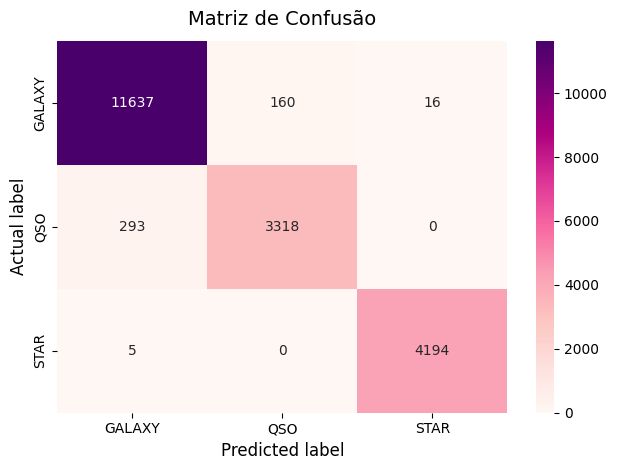

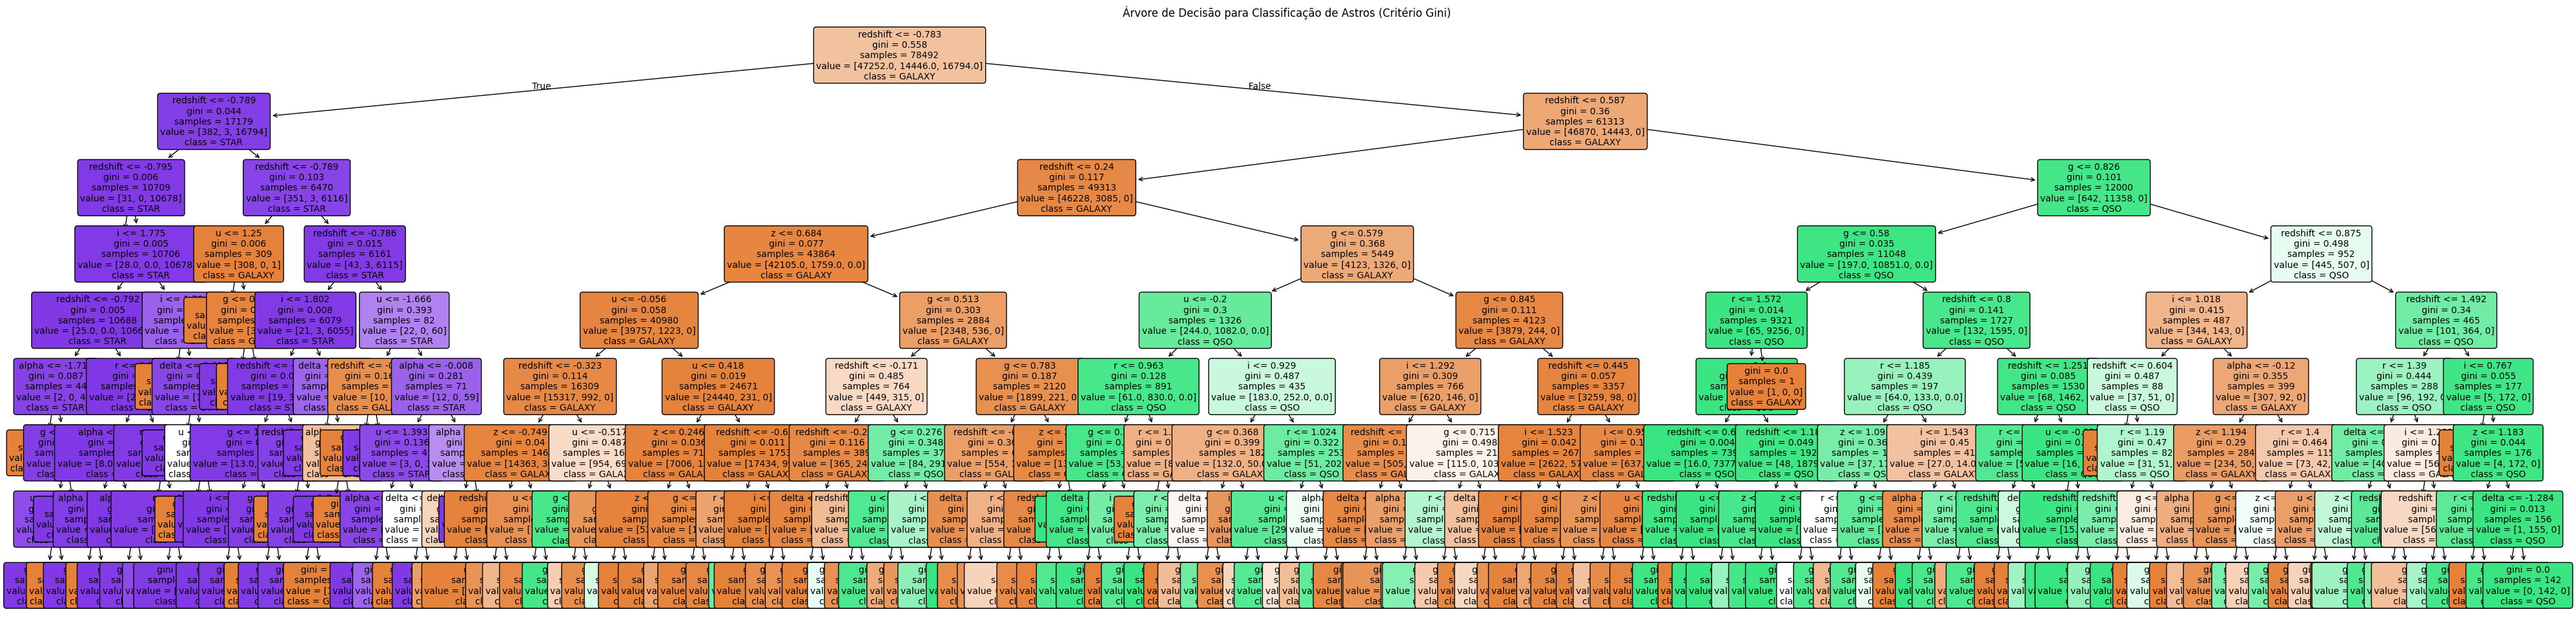

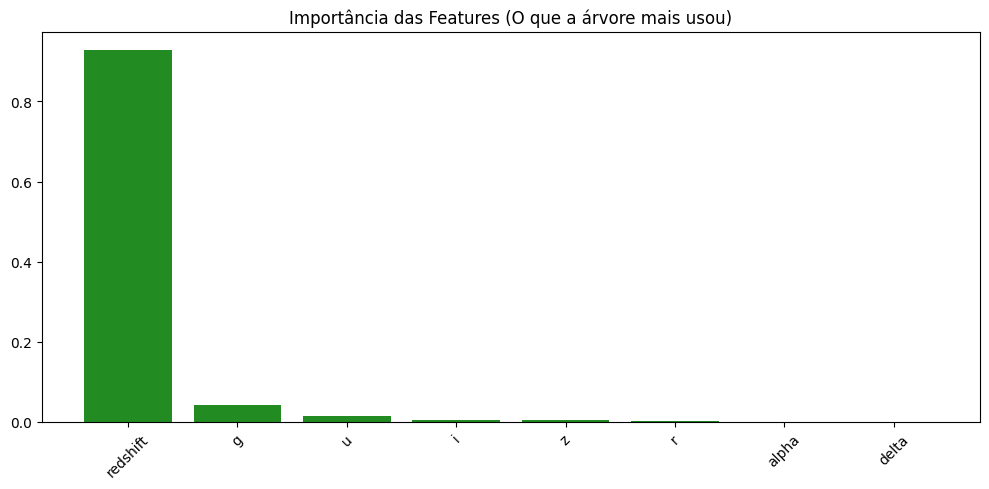

In [ ]:
tree_clf = DecisionTreeClassifier(
    criterion='gini', #função de ganho (CART USA GINI)
    max_depth=8,
    random_state=42
)
tree_clf.fit(starsTrain, classTrain)

starsPredictedDT = tree_clf.predict(starsTest)

# Evaluate the performance of the SVM classifier
print('Classification Report:')
print(classification_report(classTest, starsPredictedDT, target_names=le.classes_)) #usa nome das classes antes de codificar

#matriz de confusão
cmDT = confusion_matrix(classTest, starsPredictedDT)
plt.figure()
sns.heatmap(cmDT, annot=True, fmt='g', cmap='RdPu', xticklabels=le.classes_,  yticklabels=le.classes_)
plt.title('Matriz de Confusão', y=1.02, fontsize=14)
plt.ylabel('Actual label', fontsize=12)
plt.xlabel('Predicted label', fontsize=12)
plt.tight_layout()
plt.show()

#visualização da árvore
plt.figure(figsize=(50, 12))
plot_tree(
    tree_clf,
    feature_names=starsFeatures.columns,
    class_names=le.classes_, # 'malignant', 'benign'
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Árvore de Decisão para Classificação de Astros (Critério Gini)")
plt.show()

#confirmar features mais usadas
importances = tree_clf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.title("Importância das Features (O que a árvore mais usou)")
plt.bar(range(starsFeatures.shape[1]), importances[indices], align="center", color='forestgreen')
plt.xticks(range(starsFeatures.shape[1]), starsFeatures.columns[indices], rotation=45)
plt.tight_layout()
plt.show()

<h1>Comparação Final</h1>

<h3>Desempenho Geral</h3>

Observa-se que todos os modelos tiveram excelente desempenho, alcançando acurácia superior à 95%. Isso se deve, em partes, pela qualidade e características do dataset escolhido.

Como evidenciado na **Análise Exploratória**, o atributo _redshift_ tem forte capacidade para, por si só, discriminar perfeitamente **Estrelas**,  também **Quasares distantes** (valores maiores desta variável)

Além disso, o tratamento prévio dos dados garantiu remoção de outliers (DBSCAN) e ruídos que poderiam "confundir" as fronteiras/planos de decisão dos modelos.

<h3>Comparação dos modelos</h3>

* **Regressão Logística**: foi o modelo com menor desempenho, mesmo que ainda seja alto. Tal resultado confirma que os dados são linearmente separáveis (visto que esse modelo teve um resultado tão satisfatório), mas não em sua totalidade. A regressão logística "transforma" a combinação linear dos dados de entrada para que se encaixem no intervalo [0 1] para cálculo da sua probabilidade e, assim, classificação. Dessa forma, as instâncias que se sobrepõem em alguma característa (como Gálaxias e Quasares em certos valores de Redshift), contribuem para falha do modelo em classificar algumas amostras.

* **SVM e MLP**: SVM e MLP (A Refinação Não-Linear): O SVM (com kernel RBF) e o MLP apresentaram desempenho  muito semelhante. O uso do kernel RBF permitiu ao SVM traçar fronteiras curvas suaves ao redor dos grupos de Quasares, corrigindo erros que a Regressão Logística cometeu ao não captar os dados não lineamente separáveis. Como ambos operam em espaços de características superiores, conseguiram "linearizar" a separação desses pontos sobrespostos, o que garante seu melhor desepenho frente o modelo de **Regressão Logística**.

  * Custo x Benefício: O SVM é a alternativa mais eficiente entre os dois para este dataset (visto que é de médio porte, com relações não tão complexas) e, atingindo a  mesma performance da Rede Neural (MLP). Ademais, necessita de menos custo computacional para o conjunto de dados em questão(funções de kernel permitem operar nesses espaços de dimensão superior sem precisar aplicar a transformação linear nos dados de entrada, como o MLP) e memória, já que considera apenas os vetores de suporte (dados que influenciam na classificação), descartando boa parte dos dados do conjunto com baixa ou nenhuma influência na decisão (graças aos coeficientes de Lagrange)

* **Árvore de Decisão**: Com 98% de acurácia, foi o modelo de melhor desempenho. Sua natureza não-paramétrica permitiu criar "caixas" de decisão perfeitas (if redshift > x then...), e adequando suas fronteiras de decisão à medida que aprendia as regras (priorizando atributos com maior ganho de informação). Além disso, é o modelo com maior interpretabilidade entre todos, sendo "fácil" identificar o caminho percorrido de uma decisão. Para o dataset utilizado, as _features_ (principalmente redshift, utilizado como primeiro parâmetro de discriminação pela árvore) garantiam uma divisão rápida do conjunto de dados. Atribui-se seu sucesso também à sua capacidade de "segregar" as classes rapidamente, com "condições/perguntas" que separaram bem o conjunto de dados, e afunilaram a decisão com eficácia.

<h3>Problema da Classe Quasar (QSO)</h3>

É evidente que em todos os modelos, a classe Quasar apresentou as menores métricas (recall, precision e f1-score).

Motivo Físico: Quasares são Núcleos Galácticos Ativos. Fisicamente, eles são galáxias com um buraco negro supermassivo ativo. A semelhança em relação aos comprimentos de onda(cores u, g, r, i, z) entre uma Galáxia normal e um Quasar é imensa. Com isso, as demais features dessa classe se sobrepunham em muitas intâncias aos valores apresentados de galáxias.

Considerando os "outliers" da classe Gálaxia para redshift (mesmo intervalo de valores de Quasar), as demais features também teriam maior peso na decisão. Portanto, por apresentar valores semelhantes nas demais, e, nesses casos especiais, em redshift também, foi a classe mais sensível à classificação incorreta em todos os modelos.
  * Tanto é que, à parte do modelo de Regressão Logística (que classificou incorretamente também um Quasar como Estrela), percebe-se pela matriz de confusão que os Quasares classificados incorretamente foram todos indicados como Galáxias.

<h2>Conclusão</h2>

Conclusão: Para este dataset específico, a **Árvore de Decisão** mostrou-se a melhor escolha, combinando a maior acurácia, complexidade reduzida perante os modelos de melhor desempenho e baixo custo computacional em comparação com modelos como MLP (usou-se Índice de Gini para cálculo do ganho de informação, oq eu contribui para a redução de seu custo computacional também). Sua alta interpretabilidade também é uma grande vantagem, a fim de utilizar o modelo para explicações de "como" os astros foram classificados.

In [ ]:
from google.colab import files
import os

print("--- PASSO 1: Envie o arquivo .ipynb que você baixou ---")
# Isso vai abrir um botão para você escolher o arquivo no seu computador
uploaded = files.upload()

for nome_arquivo in uploaded.keys():
    print(f"\nArquivo recebido: {nome_arquivo}")
    print("--- PASSO 2: Convertendo para HTML... ---")

    # Instala o conversor se não tiver
    os.system('pip install nbconvert')

    # Comando de conversão forçado
    # O comando 'jupyter nbconvert' cria o HTML a partir do arquivo que você acabou de subir
    retorno = os.system(f'jupyter nbconvert --to html "{nome_arquivo}"')

    if retorno == 0:
        arquivo_html = nome_arquivo.replace('.ipynb', '.html')
        print(f"--- PASSO 3: Sucesso! Baixando {arquivo_html}... ---")
        files.download(arquivo_html)
    else:
        print("Erro na conversão. Verifique se o nome do arquivo não tem caracteres muito estranhos.")

--- PASSO 1: Envie o arquivo .ipynb que você baixou ---


Saving classificacaoFinal.ipynb to classificacaoFinal (1).ipynb

Arquivo recebido: classificacaoFinal (1).ipynb
--- PASSO 2: Convertendo para HTML... ---
--- PASSO 3: Sucesso! Baixando classificacaoFinal (1).html... ---


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>